# 因果推論：FRB金利 → 日経225 への影響分析

## 目的
- 米国の金利政策（FOMC）が日経225に影響を与えているかを検証
- Granger因果性テストで「金利変化 → 株価変化」の因果関係を統計的に判定
- イベント研究（Event Study）でFOMC前後の株価変動を分析

## なぜ因果推論が重要か
「金利が上がると株価が下がる」は直感的にわかるが、
それは本当に因果関係か？ただの相関か？
統計的に因果の方向性を検証することで、分析の信頼性を高める。

## Granger因果性テストとは
「Xの過去の値が、Yの予測に役立つか？」を検定する手法。
- 役立つなら → 「XはYにGranger因果する」（X → Y の因果あり）
- 役立たないなら → 因果関係は認められない

In [2]:
# ライブラリのインポート
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']=(14,7)
sns.set_style('whitegrid')

print("✓ ライブラリのインポート完了")

✓ ライブラリのインポート完了


## 1. データ取得
- 日経225の株価データ
- 米国10年国債利回り（金利の代理変数として使用）

※ FRBの政策金利そのものは頻繁に変わらないため、
  市場が織り込む「期待金利」を反映する10年国債利回りを使う。

In [3]:
#日経225　データ取得
nikkei = yf.download('^N225', start='2019-01-01')
nikkei.columns = nikkei.columns.get_level_values(0)

# 米国10年国債利回り(^TNX)データ取得
tnx = yf.download('^TNX', start='2019-01-01')
tnx.columns = tnx.columns.get_level_values(0)

print(f"【データ取得結果】")
print(f"  日経225:        {len(nikkei)} 日分")
print(f"  米国10年国債:   {len(tnx)} 日分")

#両方のデータを結合（日付で結合、両方にある日だけ残す）
df = pd.DataFrame({
    'nikkei_close': nikkei['Close'],
    'us10y_yield': tnx['Close']
}).dropna()

print(f"  結合後データ:   {len(df)} 日分")
print(f"  期間: {df.index[0].strftime('%Y-%m-%d')} 〜 {df.index[-1].strftime('%Y-%m-%d')}")
print(f"\n【最新5日のデータ】")
print(df.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

【データ取得結果】
  日経225:        1765 日分
  米国10年国債:   1822 日分
  結合後データ:   1702 日分
  期間: 2019-01-04 〜 2026-03-31

【最新5日のデータ】
            nikkei_close  us10y_yield
Date                                 
2026-03-25  53749.621094        4.328
2026-03-26  53603.648438        4.416
2026-03-27  53373.070312        4.440
2026-03-30  51885.851562        4.342
2026-03-31  51063.718750        4.311


## 2. 日次変化率の計算 + 相関分析
株価と金利の「動き」を比較するために、変化率（リターン）に変換する。

なぜ変化率に変換するか：
- 株価は20000〜55000円、金利は0.5〜5%。スケールが全然違う
- 「昨日からどれだけ動いたか（%）」に揃えることで比較可能になる

In [4]:
#日次変化率を計算
df['nikkei_return']=df['nikkei_close'].pct_change() * 100
df['yield_change'] = df['us10y_yield'].diff() # 金利は差分(%ポイント)

#欠損値を除去
df_clean= df.dropna()

print(f"【日次変化率の統計】")
print(f"\n日経225 リターン（%）:")
print(df_clean['nikkei_return'].describe())
print(f"\n米国10年国債 利回り変化（%pt）:")
print(df_clean['yield_change'].describe())

【日次変化率の統計】

日経225 リターン（%）:
count    1701.000000
mean        0.065974
std         1.381424
min       -12.395758
25%        -0.636178
50%         0.085242
75%         0.776592
max        10.226327
Name: nikkei_return, dtype: float64

米国10年国債 利回り変化（%pt）:
count    1701.000000
mean        0.000971
std         0.061044
min        -0.355000
25%        -0.034000
50%         0.000000
75%         0.036000
max         0.269000
Name: yield_change, dtype: float64


## 3. 相関分析
まず「金利と株価に関係がありそうか」を相関係数で確認する。

注意：相関 ≠ 因果
- 相関：「一緒に動く」（AとBが同時に上がる）
- 因果：「Aが原因でBが動く」（Aが先に動き、その後Bが動く）

相関があっても因果があるとは限らない。因果の検証は Granger テストで行う。

【相関分析結果】
  日経225リターン × 金利変化 の相関係数: 0.0767
  → 非常に弱い正の相関
  → 金利が上がると株価は上がる傾向（ただし相関のみ）


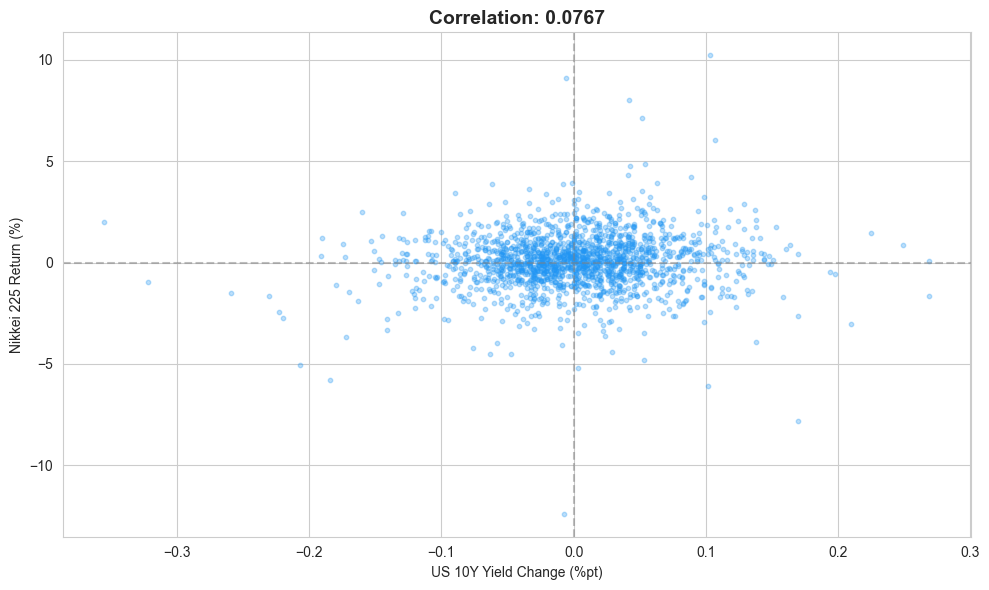

In [5]:
#相関係数の計算
correlation = df_clean['nikkei_return'].corr(df_clean['yield_change'])

print(f"【相関分析結果】")
print(f"  日経225リターン × 金利変化 の相関係数: {correlation:.4f}")

if abs(correlation) < 0.2:
    strength = "非常に弱い"
elif abs(correlation) < 0.4:
    strength = "弱い"
elif abs(correlation) < 0.6:
    strength = "中程度"
else:
    strength = "強い"

direction = "正の" if correlation > 0 else "負の"
print(f"  → {strength}{direction}相関")
print(f"  → 金利が上がると株価は{'上がる' if correlation > 0 else '下がる'}傾向（ただし相関のみ）")

#散布図
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df_clean['yield_change'], df_clean['nikkei_return'], alpha=0.3, s=10, color='#2196F3')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('US 10Y Yield Change (%pt)')
ax.set_ylabel('Nikkei 225 Return (%)')
ax.set_title(f'Correlation: {correlation:.4f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Granger 因果性テスト  核心部分

問い：「米国金利の変化は、日経225の変動を予測するのに役立つか？」

### 仮説
- 帰無仮説（H₀）： 金利変化は株価変動の予測に役立たない（因果なし）
- 対立仮説（H₁）： 金利変化は株価変動の予測に役立つ（因果あり）

### テストの仕組み
1. 日経225の過去データだけで明日の株価を予測するモデルを作る
2. そこに金利の過去データも加えて予測するモデルを作る
3. 金利を加えた方が「統計的に有意に予測精度が上がる」なら因果あり

### ラグ（遅延）
「金利が変わった翌日に株価が反応」「2日後に反応」…何日後まで影響があるかも調べる。

In [7]:
# Granger 因果性テスト
print("=" * 60)
print("【Granger 因果性テスト】")
print("帰無仮説:　金利変化は日経225の予測に役立たない")
print("　対立仮設:　金利変化は日経225の予測に役立つ")
print("=" * 60)

#テスト実施(ラグ１～5日で検証)
test_data = df_clean[['nikkei_return', 'yield_change']].values
max_lag = 5
results = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)

print(f"\n{'ラグ':>4} | {'F統計量':>10} | {'p値':>10} | {'判定':>8}")
print("-" * 50)

significant_lags = []

for lag in range(1, max_lag + 1):
    f_stat = results[lag][0]['ssr_ftest'][0]
    p_value = results[lag][0]['ssr_ftest'][1]
    sig = "✓ 有意" if p_value < 0.05 else "x"

    if p_value < 0.05:
        significant_lags.append(lag)

    print(f"{lag:>4} | {f_stat:>10.4f} | {p_value:>10.6f} | {sig:>8}")

print("\n" + "=" * 60)
if significant_lags:
    print(f"✓ 結論：ラグ {significant_lags} で因果関係が認められた（p < 0.05）")
    print(f"  → 金利変化は {significant_lags[0]} 日後の日経225に影響を与えている")
    print(f"  → 「金利 → 株価」の Granger 因果性が存在する")
else:
    print("✗ 結論：いずれのラグでも因果関係は認められなかった")
    print("  → 金利変化だけでは日経225の動きを予測できない")
    print("  → 他の要因（為替、景気、地政学リスク等）の影響が大きい可能性")
print("=" * 60)

【Granger 因果性テスト】
帰無仮説:　金利変化は日経225の予測に役立たない
　対立仮設:　金利変化は日経225の予測に役立つ

  ラグ |       F統計量 |         p値 |       判定
--------------------------------------------------
   1 |     5.0925 |   0.024156 |     ✓ 有意
   2 |     2.7424 |   0.064701 |        x
   3 |     1.7325 |   0.158323 |        x
   4 |     1.5191 |   0.194043 |        x
   5 |     1.4644 |   0.198416 |        x

✓ 結論：ラグ [1] で因果関係が認められた（p < 0.05）
  → 金利変化は 1 日後の日経225に影響を与えている
  → 「金利 → 株価」の Granger 因果性が存在する


## 5. イベント研究：FOMC会合前後の株価変動
FRBが金利を決定するFOMC会合の前後で、日経225がどう動くかを分析する。

In [9]:
# FOMC 会合日（2023-2024年の主要な会合）
fomc_dates = [
    '2023-02-01', '2023-03-22', '2023-05-03', '2023-06-14',
    '2023-07-26', '2023-09-20', '2023-11-01', '2023-12-13',
    '2024-01-31', '2024-03-20', '2024-05-01', '2024-06-12',
    '2024-07-31', '2024-09-18', '2024-11-07', '2024-12-18'
]

# 各FOMC前後のリターンを計算
event_results = []
window_before = 5 #会合前5日
window_after = 7 #会合後7日

for date_str in fomc_dates:
    fomc_date = pd.Timestamp(date_str)

    #データに存在する直近の営業日を探す
    available_dates = df_clean.index[df_clean.index >= fomc_date]
    if len(available_dates) == 0:
        continue
    actual_date = available_dates[0]

    # 前後の位置を取得
    idx = df_clean.index.get_loc(actual_date)

    if idx >= window_before and idx + window_after < len(df_clean):
        before_return = df_clean['nikkei_return'].iloc[idx - window_before:idx].mean()
        after_return = df_clean['nikkei_return'].iloc[idx:idx +window_after].mean()

        event_results.append({
            'fomc_date': date_str,
            'before_avg_return': before_return,
            'after_avg_return': after_return,
            'difference': after_return -before_return
        })

event_df = pd.DataFrame(event_results)

print("【イベント研究：FOMC会合前後の日経225リターン】\n")
print(f"  分析対象の FOMC 会合数: {len(event_df)} 回")
print(f"  会合前 {window_before} 日の平均リターン: {event_df['before_avg_return'].mean():.4f}%")
print(f"  会合後 {window_after} 日の平均リターン: {event_df['after_avg_return'].mean():.4f}%")

#前後の差に対するt検定

t_stat, p_value =stats.ttest_rel(
    event_df['before_avg_return'],
    event_df['after_avg_return']
)

print(f"\n【対応のあるt検定：前後の差】")
print(f"  t統計量: {t_stat:.4f}")
print(f"  p値:     {p_value:.6f}")

if p_value < 0.05:
    print(f"  → FOMC前後で日経225のリターンに有意な差がある")
else:
    print(f"  → FOMC前後で統計的に有意な差は認められない")

【イベント研究：FOMC会合前後の日経225リターン】

  分析対象の FOMC 会合数: 16 回
  会合前 5 日の平均リターン: 0.0906%
  会合後 7 日の平均リターン: 0.0673%

【対応のあるt検定：前後の差】
  t統計量: 0.1314
  p値:     0.897226
  → FOMC前後で統計的に有意な差は認められない


## 6. 結果の可視化

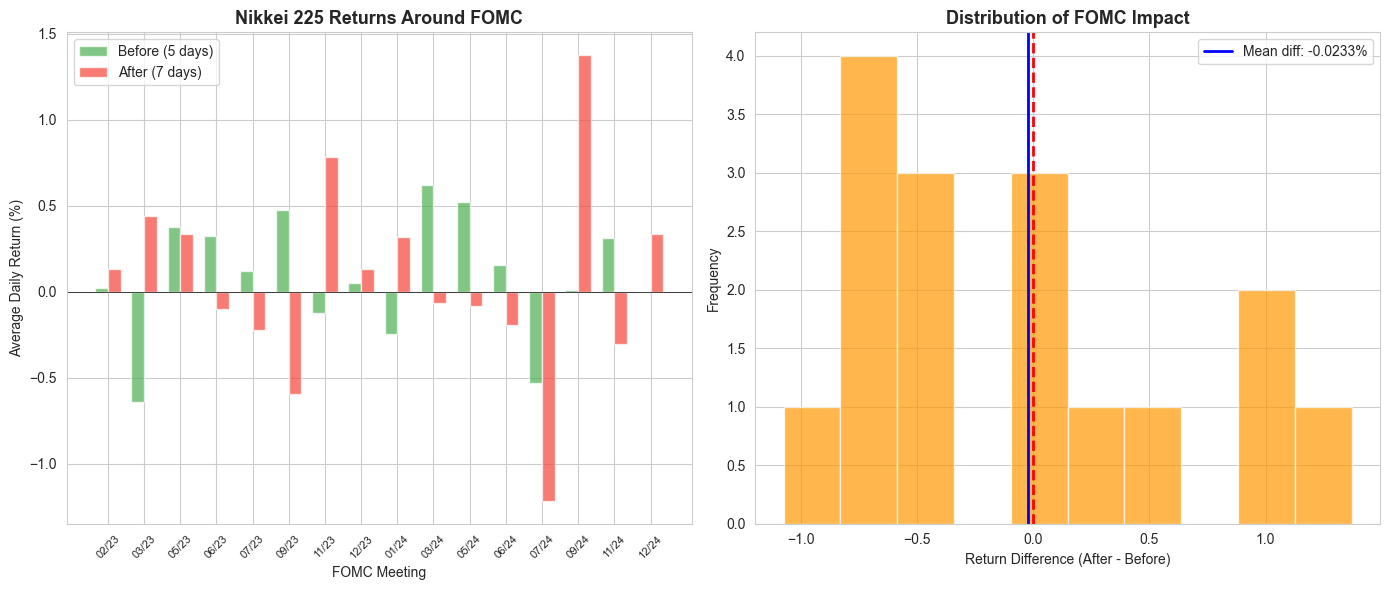

✓ FOMC イベント研究グラフ保存完了


In [10]:
#FOMC前後のリターン比較グラフ
fig, axes = plt.subplots(1,2, figsize=(14, 6))

#左:FOMC前後の平均リターン比較
x = range(len(event_df))
width = 0.35
axes[0].bar([i - width/2 for i in x], event_df['before_avg_return'], width, 
            label=f'Before ({window_before} days)', color='#4CAF50', alpha=0.7)
axes[0].bar([i + width/2 for i in x], event_df['after_avg_return'], width, 
            label=f'After ({window_after} days)', color='#F44336', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('FOMC Meeting')
axes[0].set_ylabel('Average Daily Return (%)')
axes[0].set_title('Nikkei 225 Returns Around FOMC', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_xticks(x)
axes[0].set_xticklabels([d[5:7] + '/' + d[2:4] for d in event_df['fomc_date']], rotation=45, fontsize=8)

# 右：前後の差の分布
axes[1].hist(event_df['difference'], bins=10, color='#FF9800', alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=event_df['difference'].mean(), color='blue', linestyle='-', linewidth=2,
                label=f'Mean diff: {event_df["difference"].mean():.4f}%')
axes[1].set_xlabel('Return Difference (After - Before)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of FOMC Impact', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fomc_event_study.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ FOMC イベント研究グラフ保存完了")

## 7. まとめ

### 実装内容
1. 日経225と米国金利データを取得・結合
2. 相関分析で関係性を確認
3. *Granger因果性テスト*で因果の方向性を検証
4. *イベント研究*でFOMC前後の影響を測定
5. t検定で有意性を判定

### Notebook 2 との違い
- Notebook 2：「戦略に実力があるか？」（1標本t検定）
- Notebook 3：「外部要因が株価を動かしているか？」（因果推論）

### ビジネスへの応用
- 施策の因果効果：「広告を打った→売上が上がった」は因果か相関か？
- 外部要因の分離：「売上低下は景気のせいか、自社の問題か？」
- 政策評価：「新制度導入の効果は本当にあったか？」